# Clean JSON Export Inspection

This notebook loads the latest `processed_export_*.json` from the minimal schema
and builds a quick catalog of the available tables and images grouped by section.

In [31]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

# Import the export reader library
from scraper.export_reader import load_latest_export

# Load the latest export
reader = load_latest_export()

# Print summary
reader.print_summary()

# Get documents dataframe
df_documents = reader.get_documents_dataframe()
print(f"\nLoaded {len(df_documents)} documents")


Loading latest export: processed_export_1779393593.json
EXPORT SUMMARY
Total documents: 283
Export file: /home/jgrzyb/Documents/Python/ai4es-oa-paper-scrapper/notebooks/paper_pipeline_data/exports/processed_export_1779393593.json

Documents by source:
source
pmc      264
arxiv     19

Total tables: 2387
Total images: 1727

Document sections:
  Min sections: 0
  Max sections: 49
  Avg sections: 17.5


Loaded 283 documents


## Data Parsing

In [32]:
# Get all tables as a dataframe
df_tables = reader.get_all_tables_dataframe()
print(f"Total tables: {len(df_tables)}")
display(df_tables.head(20))

# Get all images as a dataframe
df_images = reader.get_all_images_dataframe()
print(f"\nTotal images: {len(df_images)}")
display(df_images.head(20))


Total tables: 2387


,paper_id,section,table_index,global_index,csv_path
0,0903.2017,References,0,0,tables/0903.2017/table_0.csv
1,0903.2017,Radius of the double occupancies,0,1,tables/0903.2017/table_1.csv
2,0903.2017,Expansion from the harmonic trap: Reduction of...,0,2,tables/0903.2017/table_2.csv
3,PMC6004667,Results,0,0,tables/PMC6004667/table_0.csv
4,PMC6004667,Results,1,1,tables/PMC6004667/table_1.csv
5,PMC6004667,Results,2,2,tables/PMC6004667/table_2.csv
6,PMC6004667,Results,3,3,tables/PMC6004667/table_3.csv
7,PMC6004667,Characteristics of included studies,0,4,tables/PMC6004667/table_4.csv
8,PMC6004667,Prevalence of spider mite sensitization,0,5,tables/PMC6004667/table_5.csv
9,PMC6004667,"Publication bias, sensitivity, and meta-regres...",0,6,tables/PMC6004667/table_6.csv



Total images: 1727


,paper_id,section,placeholder,caption,path
0,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x5.png,Figure 5: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x5.png
1,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x6.png,Figure 6: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x6.png
2,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x7.png,Figure 7: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x7.png
3,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x8.png,Figure 8: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x8.png
4,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x9.png,Figure 9: (Color online) Dependence of the ave...,https://ar5iv.org/html/0903.2017/assets/x9.png
5,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x10.png,Figure 10: (Color online) Radius R d subscript...,https://ar5iv.org/html/0903.2017/assets/x10.png
6,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x11.png,Figure 11: (Color online) Reduction of the ent...,https://ar5iv.org/html/0903.2017/assets/x11.png
7,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x13.png,Figure 12: (Color online) Average double occup...,https://ar5iv.org/html/0903.2017/assets/x13.png
8,PMC6004667,Results,PMC_FIG_0,Fig. 1 Flow chart of screening and inclusion o...,png/PMC6004667/13601_2018_209_Fig4_HTML.jpg
9,PMC6004667,Results,PMC_FIG_1,Fig. 2 Forest plot of prevalence estimates of ...,png/PMC6004667/13601_2018_209_Fig2_HTML.jpg


## Utilities for inspection

In [33]:
def show_table(index):
    """Display a specific table from the tables dataframe."""
    if index < 0 or index >= len(df_tables):
        print('Index out of range')
        return
    
    row = df_tables.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Table Index: {row['table_index']} (Global: {row['global_index']})")
    print(f"CSV Path: {row['csv_path']}")
    print()
    
    try:
        df = reader.load_table_csv(row['csv_path'])
        display(df)
    except FileNotFoundError as e:
        print(f"Error: {e}")

def show_image(index):
    """Display a specific image from the images dataframe."""
    if index < 0 or index >= len(df_images):
        print('Index out of range')
        return
    
    row = df_images.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Caption: {row['caption']}")
    print(f"Placeholder: {row['placeholder']}")
    print()
    
    try:
        path = row['path']
        
        # Check if it's a URL (handle malformed URLs too)
        if 'http' in path.lower():
            # Try to fix malformed URLs (https:/ -> https://)
            if path.startswith('https:/') and not path.startswith('https://'):
                path = path.replace('https:/', 'https://', 1)
            elif path.startswith('http:/') and not path.startswith('http://'):
                path = path.replace('http:/', 'http://', 1)
            
            print(f"Remote image: {path}")
            display(Image(url=path))
        else:
            # Local file path
            img_path = reader.get_file_path(path)
            if Path(img_path).exists():
                display(Image(filename=img_path))
            else:
                print(f"Image file not found: {img_path}")
    except Exception as e:
        print(f"Error displaying image: {e}")

def show_document(paper_id):
    """Display complete information about a document."""
    meta = reader.get_document_metadata(paper_id)
    if meta is None:
        print(f"Document not found: {paper_id}")
        return
    
    print(f"Paper ID: {meta['paper_id']}")
    print(f"Source: {meta['source']}")
    if meta['pmcid']:
        print(f"PMCID: {meta['pmcid']}")
    if meta['arxiv_id']:
        print(f"arXiv ID: {meta['arxiv_id']}")
    print(f"Authors: {', '.join(meta['authors'][:3])}{'...' if len(meta['authors']) > 3 else ''}")
    print(f"Emails: {len(meta['emails'])} found")
    print(f"Files: MD={bool(meta['md_path'])}, HTML={bool(meta['html_path'])}, PDF={bool(meta['pdf_path'])}")
    print(f"Content: {meta['num_sections']} sections, {meta['num_tables']} tables, {meta['num_images']} images")
    print()

def show_document_sections(paper_id):
    """Display all sections and their content for a document."""
    sections = reader.load_document_sections(paper_id)
    if not sections:
        print(f"Document not found: {paper_id}")
        return
    
    for i, sec in enumerate(sections, 1):
        print(f"\n{'='*60}")
        print(f"Section {i}: {sec['heading']}")
        print(f"{'='*60}")
        
        if sec['tables']:
            print(f"\n📊 Tables ({len(sec['tables'])}):")
            for j, tbl in enumerate(sec['tables'], 1):
                print(f"\n  Table {j} (index: {tbl['table_index']}):")
                if tbl['data'] is not None:
                    display(tbl['data'])
                else:
                    print(f"  ❌ {tbl.get('error', 'Could not load data')}")
        
        if sec['images']:
            print(f"\n🖼️  Images ({len(sec['images'])}):")
            for img in sec['images']:
                print(f"  - {img['caption']} ({img['placeholder']})")


In [34]:
# Example: Show first table
if len(df_tables) > 20:
    print("Example: First table in export:")
    show_table(20)
else:
    print("No tables found in export")


Example: First table in export:
Paper: PMC11659254
Section: Results
Table Index: 1 (Global: 1)
CSV Path: tables/PMC11659254/table_1.csv



,Subgroup,Numbers of studies,Pooled OR (95% CI),Heterogeneity,P of Egger's test
0,Humidity,18.0,1.0489 (1.0061; 1.0935),"I2 = 99.933%, P < 0.001",0.9037
1,Age,NaN,NaN,NaN,NaN
2,<18 years,8.0,1.0898 (1.0290; 1.1541),"I2 = 99.892%, P < 0.001",0.6147
3,≥18 years,5.0,1.0010 (1.0003; 1.0017),"I2 = 44.445%, P = 0.13",0.2730
4,Development level,NaN,NaN,NaN,NaN
5,Developing countries or regions,9.0,1.0927 (1.0220; 1.1684),"I2 = 99.968%, P < 0.001",0.8497
6,Developed countries or regions,9.0,1.0126 (0.9651; 1.0625),"I2 = 93.271%, P < 0.01",0.7507
7,Latitude level,NaN,NaN,NaN,NaN
8,Low latitude,4.0,1.0600 (0.9921; 1.1325),"I2 = 96.897%, P < 0.01",0.4156
9,Middle latitude,8.0,1.0138 (0.9868; 1.0416),"I2 = 94.227%, P < 0.01",0.2982


## Section-Based Filtering and Content

Load and display sections by keyword, with their markdown content and metadata.

In [35]:
# Get all sections as a dataframe
df_sections = reader.get_all_sections_dataframe()
print(f"Total sections: {len(df_sections)}\n")
display(df_sections.head(15))

Total sections: 4965



,paper_id,section_index,heading,md_path,num_tables,num_images
0,0903.2017,0,References,md/0903.2017/sections/section_000_References.md,1,0
1,0903.2017,1,Electronic physics auxiliary publication servi...,md/0903.2017/sections/section_001_Electronic_p...,0,0
2,0903.2017,2,Expansion from a box trap: dependence on the i...,md/0903.2017/sections/section_002_Expansion_fr...,0,0
3,0903.2017,3,Expansion from a box trap: dependence on the p...,md/0903.2017/sections/section_003_Expansion_fr...,0,0
4,0903.2017,4,Radius of the double occupancies,md/0903.2017/sections/section_004_Radius_of_th...,1,0
5,0903.2017,5,Expansion from the harmonic trap: Reduction of...,md/0903.2017/sections/section_005_Expansion_fr...,1,8
6,PMC6004667,0,Background,md/PMC6004667/sections/section_000_Background.md,0,0
7,PMC6004667,1,Search strategy,md/PMC6004667/sections/section_001_Search_stra...,0,0
8,PMC6004667,2,Eligibility criteria,md/PMC6004667/sections/section_002_Eligibility...,0,0
9,PMC6004667,3,Data extraction,md/PMC6004667/sections/section_003_Data_extrac...,0,0


In [36]:
# Filter sections by keyword (case-insensitive)
keyword = "method"
methods_sections = df_sections[df_sections['heading'].str.contains(keyword, case=False, na=False)]
print(f"Found {len(methods_sections)} sections containing '{keyword}':\n")
display(methods_sections)

Found 192 sections containing 'method':



,paper_id,section_index,heading,md_path,num_tables,num_images
21,PMC6706894,1,Method,md/PMC6706894/sections/section_001_Method.md,0,0
44,PMC10349543,1,METHODS,md/PMC10349543/sections/section_001_METHODS.md,0,0
66,PMC11659254,1,Methods,md/PMC11659254/sections/section_001_Methods.md,0,0
121,PMC11694227,1,Methods and analysis,md/PMC11694227/sections/section_001_Methods_an...,1,1
140,PMC8974722,1,Materials and Methods,md/PMC8974722/sections/section_001_Materials_a...,1,0
...,...,...,...,...,...,...
4838,PMC8610053,2,Material and methods,md/PMC8610053/sections/section_002_Material_an...,0,0
4866,PMC9289173,1,Research Method,md/PMC9289173/sections/section_001_Research_Me...,3,8
4867,PMC9289173,2,Research Method,md/PMC9289173/sections/section_002_Research_Me...,0,0
4899,PMC11415968,7,Methods,md/PMC11415968/sections/section_007_Methods.md,0,1


In [37]:
# Load and display section content with markdown
# Pick first section from methods
if len(methods_sections) > 0:
    row = methods_sections.iloc[0]
    paper_id = row['paper_id']
    section_index = row['section_index']
    
    section_data = reader.load_section_with_content(paper_id, section_index)
    
    if section_data:
        print(f"Paper: {paper_id}")
        print(f"Section: {section_data['heading']}")
        print(f"Markdown path: {section_data['md_path']}")
        print(f"Tables: {section_data['num_tables']}, Images: {section_data['num_images']}\n")
        
        # Show markdown content preview
        if section_data['md_content']:
            content = section_data['md_content']
            preview = content[:500] + ("...[TRUNCATED]" if len(content) > 500 else "")
            print("Content preview:")
            print(preview)
else:
    print("No sections found with that keyword")

Paper: PMC6706894
Section: Method
Markdown path: md/PMC6706894/sections/section_001_Method.md
Tables: 0, Images: 0

Content preview:
## Method

 This systematic literature review was conducted and reported following the Preferred Reporting Items for Systematic Reviews and Meta-Analysis (PRISMA) [16]. The Cochrane guidance for non-randomized studies was followed for meta-analysis of the results. The protocol of this systemic review has been registered on PROSPERO with registration number CRD42019122811. An a priori set of inclusion criteria was predefined. To be included, a study had to possess features, such as: (1) clear dis...[TRUNCATED]


In [38]:
# Advanced: Filter by multiple keywords and display sections with content
keywords = ["results", "findings", "discussion"]
filtered = df_sections[df_sections['heading'].str.lower().str.contains('|'.join(keywords), regex=True, na=False)]

print(f"Found {len(filtered)} sections matching keywords: {keywords}\n")
print("=" * 80)

for idx, (_, row) in enumerate(filtered.head(5).iterrows()):
    print(f"\n[{idx+1}] Paper: {row['paper_id']} | Section: {row['heading']}")
    print(f"    Tables: {row['num_tables']}, Images: {row['num_images']}")
    
    section_data = reader.load_section_with_content(row['paper_id'], row['section_index'])
    if section_data and section_data['md_content']:
        preview = section_data['md_content'][:200]
        print(f"    Preview: {preview}...")
    print("-" * 80)

Found 567 sections matching keywords: ['results', 'findings', 'discussion']


[1] Paper: PMC6004667 | Section: Results
    Tables: 4, Images: 5
    Preview: ## Results

| Study | Prevalence (%) [95% CI] | % Weight | Country | Sample Size |
| --- | --- | --- | --- | --- |
| Tetranychus urticae |  |  |  |  |
| Astarita et al. [33] | 40.0 | 9.6 | 70.4 | 1.21...
--------------------------------------------------------------------------------

[2] Paper: PMC6004667 | Section: Discussion
    Tables: 0, Images: 0
    Preview: ## Discussion

 This review provides the first comprehensive search and synthesis of the international literature on the prevalence of spider mite sensitization. The result of our synthesis of all pre...
--------------------------------------------------------------------------------

[3] Paper: PMC6706894 | Section: Results
    Tables: 4, Images: 1
    Preview: ## Results

| Study | Type of study | Patients | Control group |
| --- | --- | --- | --- |
| I. Psychiatric co

## Finding Tables and Images by Section ID

Get tables and images from a specific section using section index, just like with markdown files.

In [39]:
# Get tables from a specific section
if len(df_sections) > 0:
    # Pick first section from filtered results
    row = df_sections.iloc[72]
    paper_id = row['paper_id']
    section_index = row['section_index']
    
    # Get all tables in this section
    section_tables = reader.get_section_tables(paper_id, section_index)
    
    print(f"Paper: {paper_id}")
    print(f"Section: {row['heading']}")
    print(f"Tables in section: {len(section_tables)}\n")
    
    # Display first table if available
    if section_tables:
        first_table = section_tables[0]
        print(f"First table (index {first_table['table_index']}):")
        try:
            df = reader.load_table_csv(first_table['csv_path'])
            display(df)
        except FileNotFoundError:
            print("Table CSV not found")
    else:
        print("No tables in this section")


Paper: PMC11659254
Section: Results
Tables in section: 2

First table (index 0):


,First author,Year,Country,Study design,Gender,Age (years),Sample size,Exposure factors,Outcomes,Quality
0,Longyan Li,2020,China,TS,"M 13,874F 16,380N 1",≤1415–64 ≥ 65,"30,255",Relative humidity (lag7),Asthma outpatient,4/5
1,Huayue Liu,2019,China,TS,"M 1,684F 2,249",18–64 ≥ 65,"3,933",Relative humidity,Asthma hospitalization,3/5
2,Sutyajeet Soneja,2016,USA,C-C,"M 45,226F 70,695",≤45–1718–64 ≥ 65,"115,923",Precipitation,Asthma hospitalization,2/5
3,Marjan Kljakovic,1998,New Zealand,TS,NaN,NaN,"3,844",Relative humidity,Consultations for asthma,2/5
4,Jae-Woo Kwon,2013,South Korea,C-C,NaN,NaN,656,Mean relative humidity,Visits to emergency room for asthma,3/5
5,Nana Mireku,2009,USA,TS,NaN,1–18,"25,401",Relative humidity,Children's asthma ED visits,4/5
6,Hehua Zhang,2020,China,TS,"M 94,854F 53,901",0–56–14 ≥ 15,"173,747",Relative humidity,Asthma outpatient,4/5
7,Toshikazu Abe,2009,Japan,TS,M 52.8%F 47.2%,≤14 > 15,"6,447",Maximum humidityPrecipitation,Visits to emergency room for asthma,4/5
8,Mitsuo Hashimoto,2004,Japan,TS,NaN,2–15,"5,559",Average relative humidity,Visits to emergency room for asthma,4/5
9,Holly Ching-yu Lam,2016,China,TS,NaN,<55–1415–59 > 59,"56,112",Relative humidity,Asthma hospitalization,4/5


Paper: PMC6004667
Section: Results
Images in section: 5

Image 1: Fig. 1 Flow chart of screening and inclusion of studies for review and analysis...
  Path: png/PMC6004667/13601_2018_209_Fig4_HTML.jpg


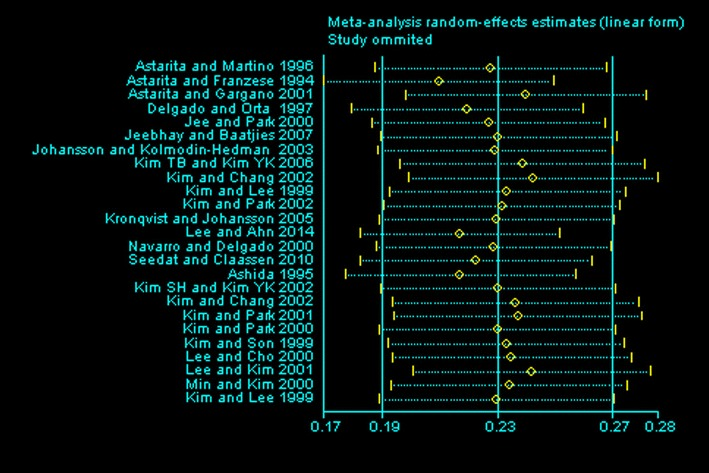

Image 2: Fig. 2 Forest plot of prevalence estimates of spider mite sensitization from inc...
  Path: png/PMC6004667/13601_2018_209_Fig2_HTML.jpg


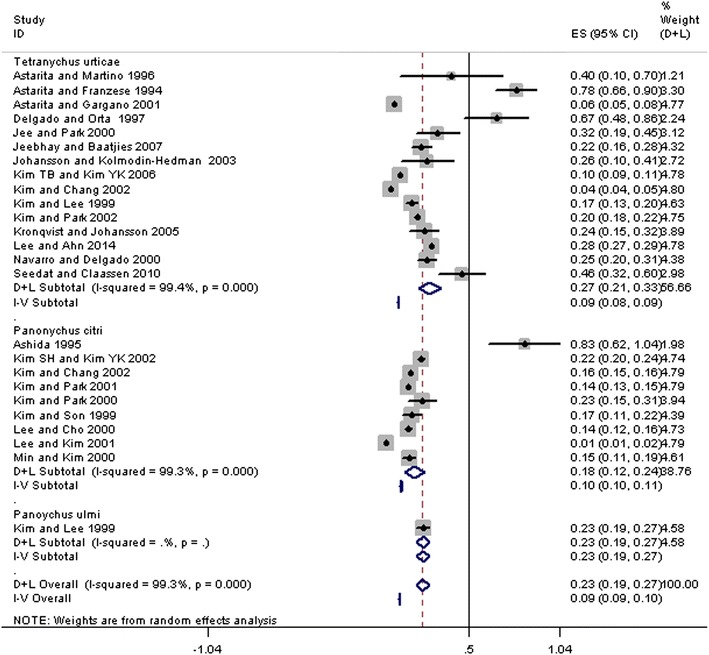

In [48]:
# Get images from a specific section
if len(df_sections) > 0:
    # Pick a section that has images
    row = df_sections[df_sections['num_images'] > 0].iloc[1] if len(df_sections[df_sections['num_images'] > 0]) > 0 else df_sections.iloc[0]
    paper_id = row['paper_id']
    section_index = row['section_index']
    
    # Get all images in this section
    section_images = reader.get_section_images(paper_id, section_index)
    
    print(f"Paper: {paper_id}")
    print(f"Section: {row['heading']}")
    print(f"Images in section: {len(section_images)}\n")
    
    if section_images:
        for i, img in enumerate(section_images[:2], 1):
            print(f"Image {i}: {img['caption'][:80]}...")
            
            # Try to display the image
            try:
                path = img['path']
                print(f"  Path: {path}")
                
                # Check if it's a URL
                if 'http' in path.lower():
                    # Try to fix malformed URLs
                    if path.startswith('https:/') and not path.startswith('https://'):
                        path = path.replace('https:/', 'https://', 1)
                    elif path.startswith('http:/') and not path.startswith('http://'):
                        path = path.replace('http:/', 'http://', 1)
                    
                    display(Image(url=path))
                else:
                    # Local file path
                    img_path = reader.get_file_path(path)
                    if Path(img_path).exists():
                        display(Image(filename=img_path))
            except Exception as e:
                print(f"  Could not display image: {e}\n")
    else:
        print("No images in this section")


In [41]:
# Example: Iterate through sections and get tables/images for a paper
if len(df_documents) > 0:
    paper_id = df_documents.iloc[0]['paper_id']
    paper_sections = df_sections[df_sections['paper_id'] == paper_id]
    
    print(f"Paper: {paper_id}")
    print(f"Total sections: {len(paper_sections)}\n")
    print("=" * 80)
    
    for _, sec_row in paper_sections.head(5).iterrows():
        section_index = sec_row['section_index']
        heading = sec_row['heading']
        
        # Get tables and images for this section
        tables = reader.get_section_tables(paper_id, section_index)
        images = reader.get_section_images(paper_id, section_index)
        
        print(f"\nSection {section_index}: {heading}")
        print(f"  Tables: {len(tables)}")
        print(f"  Images: {len(images)}")
        
        if tables:
            for t in tables[:2]:
                print(f"    - Table {t['table_index']}: {t['csv_path']}")
        if images:
            for img in images[:2]:
                print(f"    - Image: {img['caption'][:60]}...")


Paper: 0903.2017
Total sections: 18


Section 0: References
  Tables: 1
  Images: 0
    - Table 0: tables/0903.2017/table_0.csv

Section 1: Electronic physics auxiliary publication service for: Quantum distillation: dynamical generation of low-entropy states of strongly correlated fermions in an optical lattice
  Tables: 0
  Images: 0

Section 2: Expansion from a box trap: dependence on the initial filling n init subscript 𝑛 init n_{\mathrm{init}}
  Tables: 0
  Images: 0

Section 3: Expansion from a box trap: dependence on the particle number at a fixed initial filling n init subscript 𝑛 init n_{\mathrm{init}}
  Tables: 0
  Images: 0

Section 4: Radius of the double occupancies
  Tables: 1
  Images: 0
    - Table 0: tables/0903.2017/table_1.csv


## Advanced Usage Examples


In [42]:
# Example 1: Search for papers by source
pmc_papers = reader.search_papers('pmc', field='source')
print(f"PMC papers: {len(pmc_papers)}")
display(pmc_papers[['paper_id', 'source', 'num_tables', 'num_images']])


PMC papers: 264


,paper_id,source,num_tables,num_images
1,PMC6004667,pmc,8,10
2,PMC6706894,pmc,4,1
3,PMC10349543,pmc,4,17
4,PMC11659254,pmc,5,8
5,PMC6549305,pmc,14,19
...,...,...,...,...
277,PMC8610053,pmc,4,2
278,PMC11459655,pmc,0,0
279,PMC9289173,pmc,10,23
280,PMC11415968,pmc,2,16


In [43]:
# Example 2: View a complete document
if len(df_documents) > 0:
    first_paper_id = df_documents.iloc[0]['paper_id']
    print(f"Viewing document: {first_paper_id}\n")
    show_document(first_paper_id)


Viewing document: 0903.2017

Paper ID: 0903.2017
Source: arxiv
arXiv ID: 0903.2017
Authors: F. Heidrich-Meisner, S. R. Manmana, M. Rigol...
Emails: 0 found
Files: MD=True, HTML=True, PDF=False
Content: 6 sections, 3 tables, 8 images



In [44]:
# Example 3: Author summary
df_authors = reader.get_authors_summary()
print(f"Total unique authors: {len(df_authors)}")
print("\nMost prolific authors:")
display(df_authors.sort_values('num_papers', ascending=False).head(10))


Total unique authors: 1906

Most prolific authors:


,author,num_papers,papers
600,Graham Roberts,15,"[PMC10848175, PMC10099188, PMC9303769, PMC9311..."
148,Antonella Muraro,12,"[PMC10848175, PMC10099188, PMC9303769, PMC4802..."
175,Aziz Sheikh,10,"[PMC10848175, PMC10099188, PMC5883329, PMC4802..."
1102,Margitta Worm,7,"[PMC10848175, PMC10099188, PMC8248554, PMC4802..."
410,Derek K. Chu,7,"[PMC11629051, PMC8248554, PMC9478906, PMC10165..."
1349,Paul J. Turner,7,"[PMC8588837, PMC8168954, PMC8248554, PMC867481..."
257,Carina Venter,6,"[PMC10848175, PMC10099188, PMC9260209, PMC9474..."
1256,Motohiro Ebisawa,6,"[PMC4932703, PMC9515515, PMC7966874, PMC947492..."
1721,Ulugbek Nurmatov,6,"[PMC9303769, PMC4802892, PMC4746770, PMC475488..."
1531,Sangeeta Dhami,5,"[PMC4802892, PMC4746770, PMC4754882, PMC493270..."


In [45]:
# Example 4: View all sections of a document (tables + images)
if len(df_documents) > 20:
    first_paper_id = df_documents.iloc[20]['paper_id']
    print(f"Viewing all sections of: {first_paper_id}\n")
    show_document_sections(first_paper_id)


Viewing all sections of: PMC10099188


Section 1: INTRODUCTION

Section 2: Protocol registration

Section 3: Search strategy

Section 4: Inclusion and exclusion criteria

Section 5: Study selection

Section 6: Risk of bias assessment

Section 7: Data extraction

Section 8: Data analysis, synthesis, and reporting

Section 9: RESULTS

📊 Tables (2):

  Table 1 (index: 0):


,Age bands (years) for each food allergy,Self‐report,Self‐report physician diagnosis,sIgE positivity,SPT positivity,Symptom plus positive sIgE,Symptom plus positive SPT,Clinical history or FC (OFC or DBPCFC),Food challenge (OFC or DBPCFC)
0,"Point prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,≤1,1.7–28.5,2.1–4.9,19.4–20.3,1.8–4.3,1.3–4.6,1.6–13.1,2.7–10.0,0.3–4.2
2,2–5,1.6–38.7,4.9–6.6,4.1–21.5,1.8–4.5,4.6,6.8–13.1,2.1–7.7,0.0–4.2
3,6–17,1.6‐47.5,2.3–7.6,0.1–52.0,0.1‐10.2,1.4–5.6,0.1–13.1,0.2–4.2,0.1–5.7
4,≥18,1.7–36.3,0.5–11.3,2.0–25.5,21.4,0.3–5.9,—,—,0.1–3.2
5,"Life–time prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,≤1,4.1–38.4,39.3,—,—,—,—,1.0,—
7,2–5,4.1–38.4,—,—,—,—,—,15.0,—
8,6–17,4.1–41.6,2.5–27.4,—,4.1–5.9,—,—,—,—
9,≥18,9.5–35.0,4.7,—,—,—,—,—,—



  Table 2 (index: 1):


,"Reference, country",Age(s) of subjects,Frequency of FA,Comments
0,"Diwaker et al. 2017, United Kingdom29",Children 0–17 years old,Year 2000 Point prevalence of physician diagno...,Year 2015 Point prevalence of physician diagno...
1,"Gupta et al. 2004‐a, 2004‐b, and 2007, United ...",All ages,Years 1991/92 Admissions rate for FA: All ages...,Years 2000/01 Admissions rate for FA: All ages...
2,"Järvenpää et al. 2014, Finland65",Children 6–7 years old,Year 2009 Point prevalence self‐reported FA to...,Year 2013 Point prevalence self‐reported FA to...
3,"Kotz et al. 2011, United Kingdom76",All ages,Lifetime prevalence physician diagnosed peanut...,All estimates were age‐ and sex‐standardized. ...
4,Year 2001: 0.24% (0.22–0.26),Year 2002: 0.32% (0.30–0.34),Year 2003: 0.39% (0.37–0.42),Year 2004: 0.45% (0.43–0.48)
5,Incidence rate of physician diagnosed peanut a...,NaN,NaN,NaN
6,Year 2001: 0.06% (0.05–0.07),Year 2002: 0.08% (0.07–0.09),Year 2003: 0.08% (0.07–0.09),Year 2004: 0.08% (0.07–0.09)
7,"Venkataraman et al. 2017,136 Venter et al. 201...",Children 0–18 years old,"Point prevalence of self‐reported FA, SPT posi...",The data presented come from three different b...
8,Year 1990–1991 Self‐reported FA: ‐ any FA: 8.5...,Year 1995–1997 Self‐reported FA: ‐ any FA: N/A...,Year 2002–2003 Self‐reported FA: ‐ any FA: 7.2...,NaN
9,Point prevalence of self‐reported FA and of SP...,NaN,NaN,NaN



🖼️  Images (6):
  - FIGURE 1 PRISMA flow diagram for updated systematic review on prevalence of food allergy in Europe, 2000–2021. (PMC_FIG_0)
  - FIGURE 2 Pooled estimates for self‐reported any food allergy in Europe for lifetime (top) and point prevalence (bottom) between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_1)
  - FIGURE 3 Pooled estimates for self‐reported physician diagnosed any food allergy (i.e., doctor‐diagnosed FA reported by a subject in a questionnaire) for lifetime (left) and point prevalence (right) between 2012 and 2021. (PMC_FIG_2)
  - FIGURE 4 Pooled estimates for sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_3)
  - FIGURE 5 Pooled estimates for symptoms plus sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_4)
  - FIGURE 6 Pooled estimates for clinical history or food chal

,Age bands (years) for each food allergy,Self‐report,Self‐report physician diagnosis,sIgE positivity,SPT positivity,Symptom plus positive sIgE,Symptom plus positive SPT,Clinical history or FC (OFC or DBPCFC),Food challenge (OFC or DBPCFC)
0,"Point prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,≤1,1.7–28.5,2.1–4.9,19.4–20.3,1.8–4.3,1.3–4.6,1.6–13.1,2.7–10.0,0.3–4.2
2,2–5,1.6–38.7,4.9–6.6,4.1–21.5,1.8–4.5,4.6,6.8–13.1,2.1–7.7,0.0–4.2
3,6–17,1.6‐47.5,2.3–7.6,0.1–52.0,0.1‐10.2,1.4–5.6,0.1–13.1,0.2–4.2,0.1–5.7
4,≥18,1.7–36.3,0.5–11.3,2.0–25.5,21.4,0.3–5.9,—,—,0.1–3.2
5,"Life–time prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,≤1,4.1–38.4,39.3,—,—,—,—,1.0,—
7,2–5,4.1–38.4,—,—,—,—,—,15.0,—
8,6–17,4.1–41.6,2.5–27.4,—,4.1–5.9,—,—,—,—
9,≥18,9.5–35.0,4.7,—,—,—,—,—,—



🖼️  Images (5):
  - FIGURE 2 Pooled estimates for self‐reported any food allergy in Europe for lifetime (top) and point prevalence (bottom) between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_7)
  - FIGURE 3 Pooled estimates for self‐reported physician diagnosed any food allergy (i.e., doctor‐diagnosed FA reported by a subject in a questionnaire) for lifetime (left) and point prevalence (right) between 2012 and 2021. (PMC_FIG_8)
  - FIGURE 4 Pooled estimates for sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_9)
  - FIGURE 5 Pooled estimates for symptoms plus sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_10)
  - FIGURE 6 Pooled estimates for clinical history or food challenge positive any food allergy (top) and for food‐challenged verified any food allergy (bottom) in Europe between 2000 and 20

,"Reference, country",Age(s) of subjects,Frequency of FA,Comments
0,"Diwaker et al. 2017, United Kingdom29",Children 0–17 years old,Year 2000 Point prevalence of physician diagno...,Year 2015 Point prevalence of physician diagno...
1,"Gupta et al. 2004‐a, 2004‐b, and 2007, United ...",All ages,Years 1991/92 Admissions rate for FA: All ages...,Years 2000/01 Admissions rate for FA: All ages...
2,"Järvenpää et al. 2014, Finland65",Children 6–7 years old,Year 2009 Point prevalence self‐reported FA to...,Year 2013 Point prevalence self‐reported FA to...
3,"Kotz et al. 2011, United Kingdom76",All ages,Lifetime prevalence physician diagnosed peanut...,All estimates were age‐ and sex‐standardized. ...
4,Year 2001: 0.24% (0.22–0.26),Year 2002: 0.32% (0.30–0.34),Year 2003: 0.39% (0.37–0.42),Year 2004: 0.45% (0.43–0.48)
5,Incidence rate of physician diagnosed peanut a...,NaN,NaN,NaN
6,Year 2001: 0.06% (0.05–0.07),Year 2002: 0.08% (0.07–0.09),Year 2003: 0.08% (0.07–0.09),Year 2004: 0.08% (0.07–0.09)
7,"Venkataraman et al. 2017,136 Venter et al. 201...",Children 0–18 years old,"Point prevalence of self‐reported FA, SPT posi...",The data presented come from three different b...
8,Year 1990–1991 Self‐reported FA: ‐ any FA: 8.5...,Year 1995–1997 Self‐reported FA: ‐ any FA: N/A...,Year 2002–2003 Self‐reported FA: ‐ any FA: 7.2...,NaN
9,Point prevalence of self‐reported FA and of SP...,NaN,NaN,NaN



Section 20: Statement of principal findings

Section 21: Strengths, limitations, and implications of the current review update

Section 22: CONCLUSIONS

Section 23: CONFLICT OF INTEREST


Total images in export: 1727

Displaying 3 images from 20th position:

Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 2 Forest plot showing the association between probiotics and Atopic dermatitis (AD).
Placeholder: PMC_FIG_1



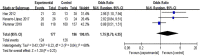



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 3 Forest plot showing the overall analysis of the SCORAD value.
Placeholder: PMC_FIG_2



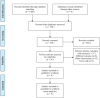



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 4 Forest plot showing subgroup analysis of SCORAD value by probiotic strain type.
Placeholder: PMC_FIG_3



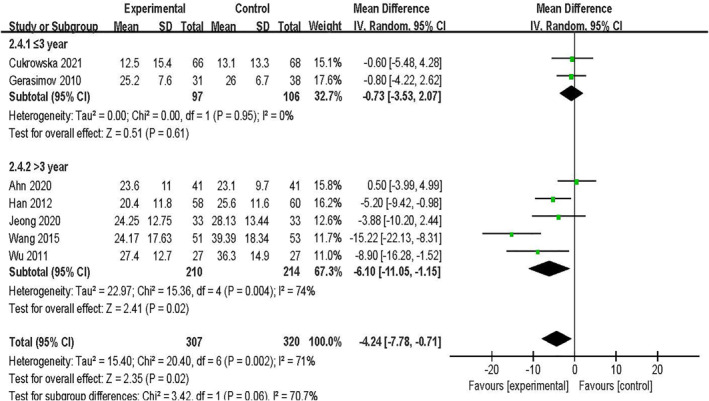

In [46]:
# Example 5: Display images from the export
if len(df_images) > 0:
    print(f"Total images in export: {len(df_images)}\n")
    print("Displaying 3 images from 20th position:\n")
    for i in range(min(20, len(df_images)), min(23, len(df_images))):
        show_image(i)
        print("\n" + "="*60 + "\n")


## Using Helper Functions

Use the helper functions below to inspect specific tables and images:

- `show_table(index)` — Display a specific table by index
- `show_image(index)` — Display a specific image by index
- `show_document(paper_id)` — Show metadata for a paper
- `show_document_sections(paper_id)` — Display all sections with tables and images

Examples:
```python
show_table(0)           # First table
show_image(0)           # First image
show_table(5)           # 6th table
show_image(3)           # 4th image
```
